In [ ]:
!pip install bertopic
!pip install nltk
# !pip install keybert
# !pip install keyphrase-vectorizers
# !pip install ctransformers[cuda]
# !pip install --upgrade git+https://github.com/huggingface/transformers

In [ ]:
import pandas as pd
import numpy as np
import torch
import transformers
from bertopic import BERTopic
import os
from sentence_transformers import SentenceTransformer
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from transformers import AutoTokenizer, pipeline
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import TextGeneration
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import openai
import lightgbm as lgb
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [ ]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df1 = pd.read_csv('../data/letters_2021_processed.csv')
df1 = df1[['s1_s2', 'full_text', 'LETTER_GENDER']]
df1 = df1.rename(columns={'LETTER_GENDER':'label'})

In [ ]:
df2 = pd.read_csv('../data/sentence_sets_trimmed_processed.csv')
df2 = df2[['s1_s2', 'full_text', 'applicant_gender']]
df2 = df2.rename(columns={'applicant_gender':'label'})

In [ ]:
df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
gender_label_mapping = {
    'F':0,
    'female':0,
    'M':1,
    'male':1
}

In [ ]:
df['label'] = df['label'].replace(gender_label_mapping)

# Process Data

In [ ]:
letters = df['s1_s2']
sentences = [sent_tokenize(letter) for letter in letters]
sentences = pd.concat([df, pd.Series(sentences, name='sentences')], axis=1)
sentences = sentences[['sentences']].explode('sentences')
df_sentences = pd.merge(df, sentences, left_index=True, right_index=True)

# Topic Modeling

In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(sentences['sentences'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/4850 [00:00<?, ?it/s]

In [ ]:
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

hdbscan_model = HDBSCAN(min_cluster_size=150, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

vectorizer_model = CountVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

In [ ]:
# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm", top_n_words=10)

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

# GPT-3.5
client = openai.OpenAI(api_key="sk-...")
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
openai_model = OpenAI(client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model,
    # "zephyr": zephyr

}

In [ ]:
topic_model = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  ctfidf_model=ctfidf_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True,
)

# Train model
topics, probs = topic_model.fit_transform(df_sentences['sentences'].tolist(), embeddings)



2025-02-13 19:31:59,005 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-02-13 19:31:59,687 - BERTopic - Guided - Completed ✓
2025-02-13 19:31:59,688 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-13 19:36:55,215 - BERTopic - Dimensionality - Completed ✓
2025-02-13 19:36:55,219 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-13 19:37:13,127 - BERTopic - Cluster - Completed ✓
2025-02-13 19:37:13,160 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-13 19:37:33,337 - BERTopic - Representation - Completed ✓


# Save Model

In [ ]:
# embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
# topic_model.save("../saved_models/topic_models/", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

# Analyze Topics

In [ ]:
topic_info = topic_model.get_topic_info()

In [ ]:
topic_info

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,-1,53256,-1_research_work ethic_learn_anesthesia,"[research, work ethic, learn, anesthesia, anes...","[medical student, anesthesiology, medical scho...","[research, work ethic, anesthesia, anesthesiol...","[research, anesthesia, anesthesiology, residen...",[[columns must add up to 100%] all university ...
1,0,22760,0_university_medical student_medical school_sc...,"[university, medical student, medical school, ...","[physician identifier, patients identifier, id...","[medical student, medical school, patients ide...","[medical student, medical school, school, cler...",[identifier completed their undergraduate s...
2,1,5471,1_rapport_differential_patients_diagnosis,"[rapport, differential, patients, diagnosis, r...","[treatment plans, plans patients, differential...","[patients, rapport patients, patient care, pat...","[rapport, differential, patients, diagnosis, d...",[they was able to present a detailed differen...
3,2,3660,2_anesthesiologist_anesthesiology_field anesth...,"[anesthesiologist, anesthesiology, field anest...","[anesthesiologist future, future anesthesiolog...","[field anesthesiology, career anesthesiology, ...","[anesthesiologist, anesthesiology, excellent a...",[they will make a fantastic resident and futu...
4,3,3532,3_medical school_school_medical student_univer...,"[medical school, school, medical student, univ...","[medical college, medical students, medical st...","[medical school, medical student, medical stud...","[medical school, school, medical student, univ...",[they completed their undergraduate degree ...
...,...,...,...,...,...,...,...,...
92,91,184,91_physical_physical exam_physical exams_physi...,"[physical, physical exam, physical exams, phys...","[examination skills, skills history, examinati...","[physical exam, physical exams, physical exami...","[physical, physical exam, physical exams, phys...",[their history taking and physical exam skill...
93,92,179,92_reservation recommend_recommend reservation...,"[reservation recommend, recommend reservation,...","[recommend reservation, reservation recommend,...","[reservation recommend, recommend reservation,...","[reservation, highest recommendation, highest,...",[i recommend their highly without reservatio...
94,93,176,93_procedures_new procedures_procedure_perform...,"[procedures, new procedures, procedure, perfor...","[procedures skills, procedures ease, skills pr...","[procedures took, procedures quickly, procedur...","[procedures, new procedures, difficult procedu...","[all of this took great confidence , and more ..."
95,94,168,94_perioperative_perioperative care_perioperat...,"[perioperative, perioperative care, perioperat...","[perioperative patients, perioperative managem...","[perioperative care, perioperative period, per...","[perioperative, perioperative care, perioperat...",[they was interested in all aspects of periop...


In [ ]:
topic_model.get_topic(1, full=True)

{'Main': [('rapport', 0.24272036099269),
  ('differential', 0.2164257308186297),
  ('patients', 0.19156873573707697),
  ('diagnosis', 0.1915522809460491),
  ('rapport patients', 0.19086350240320504),
  ('diagnoses', 0.1858783204299105),
  ('differential diagnosis', 0.1830925509180461),
  ('families', 0.1826560743826865),
  ('patient care', 0.1805624024770112),
  ('staff', 0.17955385591021694)],
 'KeyBERT': [('treatment plans', 0.5804632),
  ('plans patients', 0.5753312),
  ('differential diagnoses', 0.56154835),
  ('differential diagnosis', 0.5489423),
  ('patients ease', 0.5435877),
  ('treatment plan', 0.5329351),
  ('knew patients', 0.5321536),
  ('complex patients', 0.52170074),
  ('diagnoses', 0.52141607),
  ('patients', 0.5076041)],
 'MMR': [('patients', 0.19156873573707697),
  ('rapport patients', 0.19086350240320504),
  ('patient care', 0.1805624024770112),
  ('patients families', 0.17710551872350794),
  ('differential diagnoses', 0.1634316049864256),
  ('patients staff', 0.163

In [ ]:
topic_labels = topic_model.generate_topic_labels(nr_words=5,
                                                 topic_prefix=True,
                                                 word_length=100,
                                                 separator="||",
                                                 aspect='POS')

In [ ]:
topic_model.set_topic_labels(topic_labels)

In [ ]:
topic_mapping = dict(zip(topic_model.get_topic_info()['Topic'], topic_model.get_topic_info()['CustomName']))
topic_mapping = {f'topic_{key}': value for key, value in topic_mapping.items()}

In [ ]:
df_sentences['topic'] = topics

# Create Topics Dataframe

In [ ]:
topics_df = df_sentences.copy()
topics_df['topic'] = topics_df['topic'].astype(str)
topics_df = topics_df.groupby(topics_df.index).agg({'topic':' '.join})
topics_df = pd.DataFrame(topics_df)
topics_df = topics_df['topic'].apply(lambda x:x.split(' '))
topics_df = topics_df.reset_index()
all_topics = set(cat for sublist in topics_df['topic'] for cat in sublist)
for topic in all_topics:
    topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)
topics_df = topics_df.drop(columns=['index', 'topic'])
topics_df.columns = 'topic_' + topics_df.columns
df_sentences_collapsed = df_sentences[['s1_s2', 'full_text', 'label']].drop_duplicates()
topics_df = pd.merge(df_sentences_collapsed, topics_df, left_index=True, right_index=True)

# Build ML Model

In [ ]:
X = topics_df.drop(columns=['s1_s2', 'full_text', 'label'])
y = topics_df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
skf = StratifiedKFold(n_splits=5)

In [ ]:
# clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf = lgb.LGBMClassifier(is_unbalance=True, n_estimators=2000, verbose=-1)

In [ ]:
best_classifier = None
best_f1_score = float('-inf')
for i, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {i}:")
    # print(f"  Train: index={train_index}")
    # print(f"  Test:  index={val_index}")

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    clf.fit(X_train_fold, y_train_fold)

    y_pred = clf.predict(X_val_fold)

    print(classification_report(y_val_fold, y_pred))

    print(confusion_matrix(y_val_fold, y_pred))

    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    if f1 > best_f1_score:
      print('BEST F1 SCORE: ', f1)
      best_f1_score = f1
      best_classifier = clf






Fold 0:
              precision    recall  f1-score   support

           0       0.32      0.29      0.30       446
           1       0.69      0.72      0.71       991

    accuracy                           0.59      1437
   macro avg       0.51      0.50      0.50      1437
weighted avg       0.58      0.59      0.58      1437

[[128 318]
 [275 716]]
BEST F1 SCORE:  0.5812658110412972
Fold 1:
              precision    recall  f1-score   support

           0       0.32      0.29      0.30       446
           1       0.69      0.72      0.71       991

    accuracy                           0.59      1437
   macro avg       0.50      0.50      0.50      1437
weighted avg       0.58      0.59      0.58      1437

[[128 318]
 [277 714]]
Fold 2:
              precision    recall  f1-score   support

           0       0.30      0.25      0.27       446
           1       0.69      0.73      0.71       991

    accuracy                           0.59      1437
   macro avg       0.49

Most Important Features:
                                              Feature  Importance
62  1||rapport||differential||patients||diagnosis|...        4265
4   2||anesthesiologist||anesthesiology||excellent...        3755
84  4||residency||highest recommendation||program|...        3211
27  3||medical school||school||medical student||un...        2862
24  6||resident||residency||asset||outstanding res...        2505
46  5||anesthesia||elective||anesthetic||rotation|...        2399
47  10||asset||program||lucky||great asset||instit...        1538
63  11||calm||intelligent||demeanor||personable||m...        1479
75  9||anesthetic||anesthesia||anesthetic plans||g...        1438
71  13||player||team||great team||excellent team||...        1374
70  0||medical student||medical school||school||cl...        1156
33  12||publication||publications||author||researc...        1145
41         8||airway||iv||intubation||placement||mask        1141
64  15||questions||thoughtful questions||curious||.

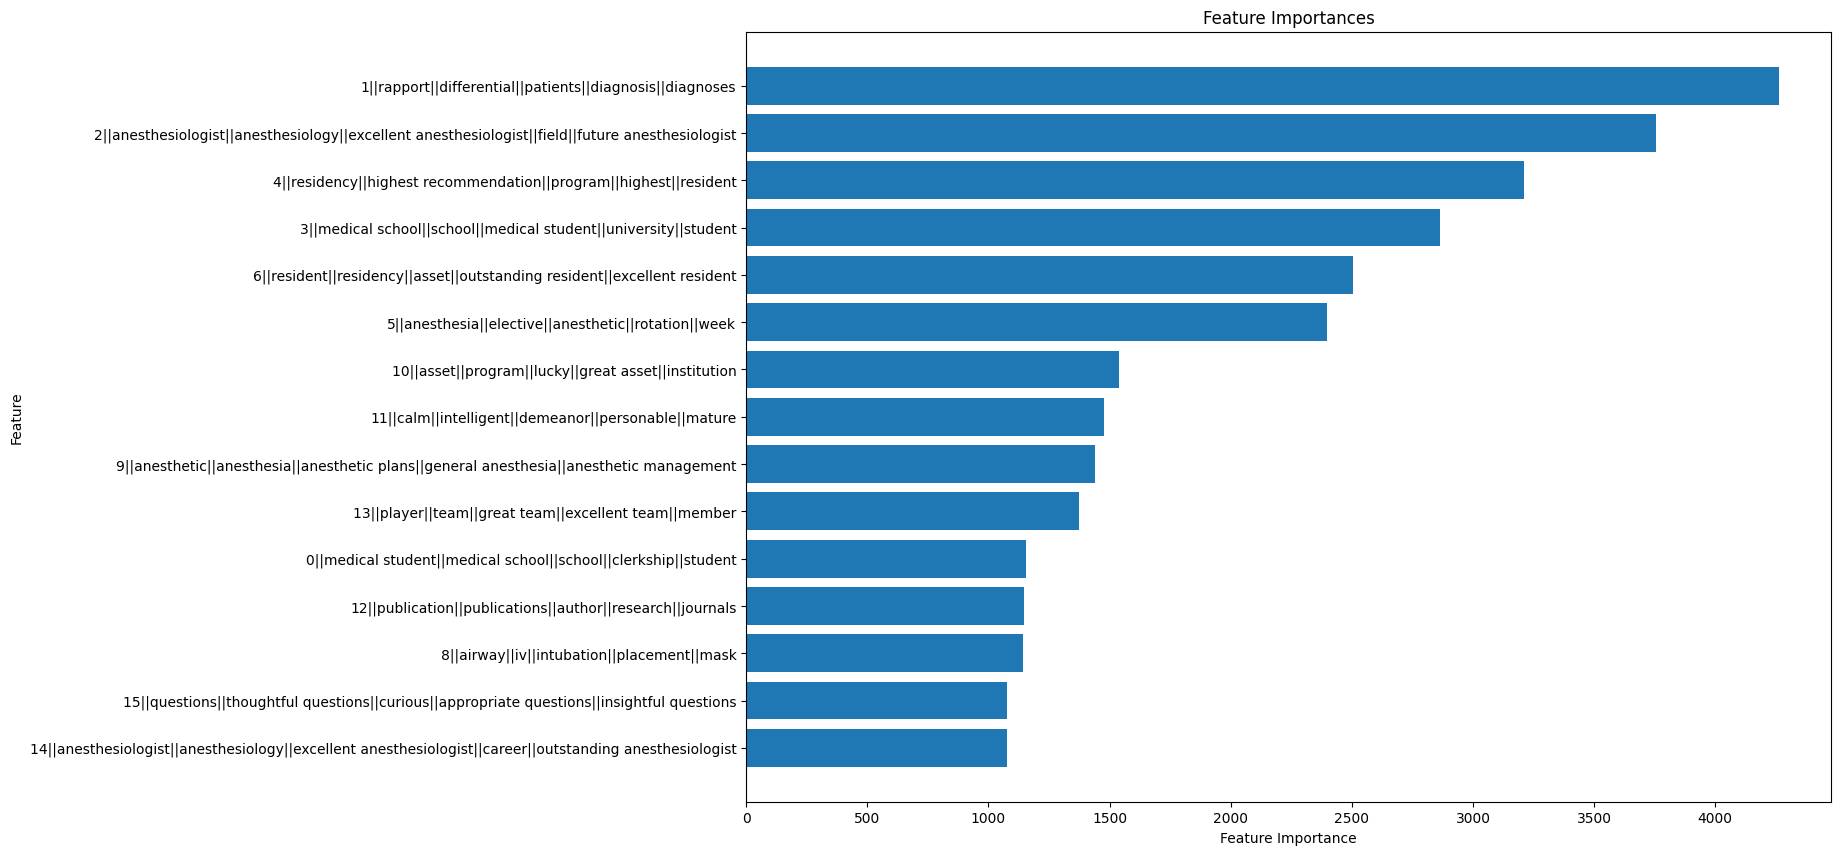

In [ ]:
importances = best_classifier.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[:15]
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(topic_mapping)

print("Most Important Features:")
print(feature_importance_df)

plt.figure(figsize=(14, 10))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')

plt.gca().invert_yaxis()

plt.show()

# Apply on Test Set

In [ ]:
y_test_preds = best_classifier.predict(X_test)

In [ ]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           0       0.34      0.32      0.33       557
           1       0.70      0.72      0.71      1239

    accuracy                           0.60      1796
   macro avg       0.52      0.52      0.52      1796
weighted avg       0.59      0.60      0.59      1796



# Analyze Important Topics

In [ ]:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)
topic_model.visualize_documents(sentences['sentences'].tolist(), hide_annotations=True, reduced_embeddings=reduced_embeddings)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,KeyBERT,MMR,POS,POS_KeyBERT,Representative_Docs
0,-1,37372,-1_pain_research_surgery_residents,-1||pain||research||surgery||residents||students,"[pain, research, surgery, residents, contact, ...","[dr identifier, medical students, identifier i...","[pain, residents, contact, students, reservati...","[pain, research, surgery, residents, students,...","[dr identifier, medical students, identifier i...",[ identifier am writing to recommend identif...
1,0,21415,0_medicine_medical_dr_dr identifier,0||medicine||medical||school||medical student|...,"[medicine, medical, dr, dr identifier, univers...","[patients identifier, identifier clinical, ide...","[dr identifier, medical student, medical schoo...","[medicine, medical, school, medical student, c...","[patients identifier, identifier clinical, ide...",[i have personally known dr. identifier sinc...
2,1,20435,1_patients_patient_care_clinical,1||patients||patient||care||clinical||physician,"[patients, patient, care, clinical, physician,...","[clinical skills, patients, care patients, pat...","[patients, physician, staff, patient care, rap...","[patients, patient, care, clinical, physician,...","[clinical skills, patients, care patients, pat...",[they had excellent rapport with both their ...
3,2,14486,2_individual_work_person_identifier,2||individual||work||person||identifier||personal,"[individual, work, person, identifier, work id...","[learn identifier, identifier intelligent, ide...","[individual, work identifier, intelligent, wor...","[individual, work, person, identifier, persona...","[learn identifier, identifier intelligent, ide...",[identifier identifier is a hardworking and...
4,3,11782,3_anesthesiology_anesthesia_anesthesiology res...,3||anesthesiology||anesthesia||anesthesiologis...,"[anesthesiology, anesthesia, anesthesiology re...","[identifier anesthesiology, anesthesiology ide...","[anesthesiology, anesthesiology residency, ide...","[anesthesiology, anesthesia, anesthesiologist,...","[identifier anesthesiology, anesthesiology ide...",[ampeectionus l / iscascs i strongly recommend...
5,4,11529,4_questions_feedback_learn_hard,4||questions||feedback||hard||eager||ethic,"[questions, feedback, learn, hard, eager, ethi...","[skills, learner, thoughtful questions, knowle...","[questions, feedback, work ethic, presentation...","[questions, feedback, hard, eager, ethic, pres...","[skills, learner, thoughtful questions, knowle...","[they was very inquisitive, asked excellent q..."
6,5,4285,5_anesthesiologist_anesthesiology_career anest...,5||anesthesiologist||anesthesiology||career||f...,"[anesthesiologist, anesthesiology, career anes...","[career anesthesiologist, anesthesiologist fut...","[anesthesiologist, career anesthesiology, fiel...","[anesthesiologist, anesthesiology, career, fie...","[career anesthesiologist, anesthesiologist fut...",[they will make an excellent anesthesiologist...
7,6,3634,6_anesthesia_anesthetic_anesthesia team_anesth...,6||anesthesia||anesthetic||anesthetic plans||p...,"[anesthesia, anesthetic, anesthesia team, anes...","[anesthesia residents, anesthesia career, care...","[anesthesia team, career anesthesia, field ane...","[anesthesia, anesthetic, anesthetic plans, pla...","[anesthesia residents, anesthesia career, care...","[regarding clinical tasks, such as perioperati..."
8,7,3000,7_residency program_residency_identifier resid...,7||residency||program||resident||candidate||po...,"[residency program, residency, identifier resi...","[residency identifier, identifier residency, r...","[residency program, recommend identifier, posi...","[residency, program, resident, candidate, posi...","[residency identifier, identifier residency, r...",[i highly recommend identifier to you as an ...
9,8,2777,8_mx_mx pleasure_support mx_recommend mx,8||pleasure||letter||support||recommendation||...,"[mx, mx pleasure, support mx, recommend mx, re...","[mx letter, recommendation mx, mx delighted, m...","[mx pleasure, support 